Loaded 57500 rows | mean=21.00 ms | p95=93.51 ms | p99=238.12 ms


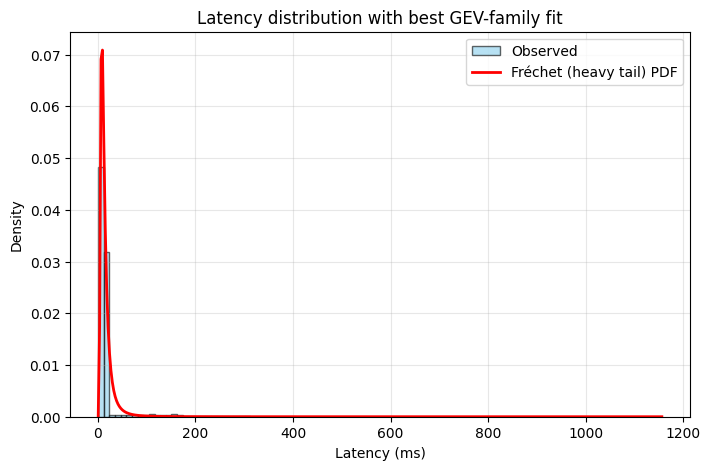

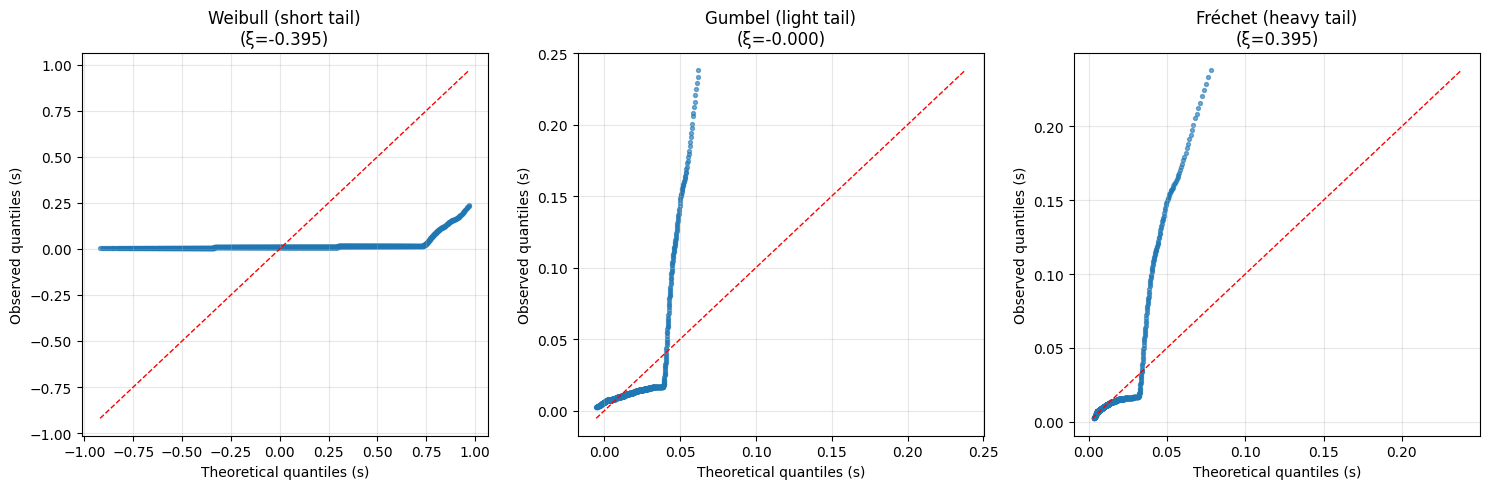

Goodness-of-fit (KS vs fitted CDF):
Weibull (short tail)      KS=0.5565  p=0.0000  (xi=-0.3947, c=0.3947, loc=0.019692, scale=0.448362)
Gumbel (light tail)       KS=0.3755  p=0.0000  (xi=-0.0000, c=0.0000, loc=0.011370, scale=0.010990)
Fréchet (heavy tail)      KS=0.2023  p=0.0000  (xi=0.3947, c=-0.3947, loc=0.009584, scale=0.005248)

Best by KS: Fréchet (heavy tail)


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.stats import genextreme, kstest, lognorm
import warnings
warnings.filterwarnings("ignore")
latencies = df[lat_col].astype(float).values

shape, loc, scale = genextreme.fit(latencies)

folder_path = "./results/20250810_211308/consumer/consumer-sts-0_consumer-result/2025-08-10/20-25-02/"
lat_col = "end_to_end_latency_seconds"   # keep EVERYTHING in seconds

csv_paths = sorted(glob.glob(folder_path + "*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSVs in {folder_path}")

dfs = [pd.read_csv(p) for p in csv_paths]
df = pd.concat(dfs, ignore_index=True)

s = pd.to_numeric(df[lat_col], errors="coerce").dropna().astype(float)
s = s[np.isfinite(s)]
s = s[s >= 0]
x = s.values  

print(f"Loaded {len(x)} rows | mean={x.mean()*1000:.2f} ms | p95={np.percentile(x,95)*1000:.2f} ms | p99={np.percentile(x,99)*1000:.2f} ms")


def fit_gev(data, c_fixed=None):
    if c_fixed is None:
        c, loc, scale = genextreme.fit(data)
    else:
        c, loc, scale = genextreme.fit(data, fc=c_fixed)
    xi = -c  # report ξ
    return dict(c=c, xi=xi, loc=loc, scale=scale)

free = fit_gev(x)
c_mag = abs(free["c"]) if np.isfinite(free["c"]) and free["c"] != 0 else 0.1

fits = {
    "Weibull (short tail)":  fit_gev(x,  c_mag),   # ξ<0, c>0
    "Gumbel (light tail)":   fit_gev(x,  0.0),     # ξ=0, c=0
    "Fréchet (heavy tail)":  fit_gev(x, -c_mag),   # ξ>0, c<0
}

best_name, best_ks = None, 1e9
for name, pars in fits.items():
    ks, p = kstest(x, genextreme.cdf, args=(pars["c"], pars["loc"], pars["scale"]))
    if ks < best_ks:
        best_name, best_ks = name, ks
best = fits[best_name]

grid = np.linspace(x.min(), x.max(), 400)
pdf  = genextreme.pdf(grid, best["c"], loc=best["loc"], scale=best["scale"])

plt.figure(figsize=(8,5))
plt.hist(x*1000, bins=100, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Observed")
plt.plot(grid*1000, pdf/1000, "r-", lw=2, label=f"{best_name} PDF")  # divide by 1000 due to ms axis
plt.xlabel("Latency (ms)"); plt.ylabel("Density"); plt.title("Latency distribution with best GEV-family fit")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


q = np.linspace(0.01, 0.99, min(len(x), 2000))
x_q = np.quantile(x, q)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, (name, pars) in zip(axes, fits.items()):
    th_q = genextreme.ppf(q, pars["c"], loc=pars["loc"], scale=pars["scale"])
    ax.scatter(th_q, x_q, s=8, alpha=0.6)
    lo = min(th_q.min(), x_q.min()); hi = max(th_q.max(), x_q.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_title(f"{name}\n(ξ={pars['xi']:.3f})")
    ax.set_xlabel("Theoretical quantiles (s)")
    ax.set_ylabel("Observed quantiles (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


print("Goodness-of-fit (KS vs fitted CDF):")
for name, pars in fits.items():
    ks, p = kstest(x, genextreme.cdf, args=(pars["c"], pars["loc"], pars["scale"]))
    print(f"{name:25s} KS={ks:.4f}  p={p:.4f}  (xi={pars['xi']:.4f}, c={pars['c']:.4f}, loc={pars['loc']:.6f}, scale={pars['scale']:.6f})")
print(f"\nBest by KS: {best_name}")


GEV fit parameters:
  Shape (ξ): -0.4894
  Location (μ): 0.0089
  Scale (σ): 0.0062
Identified type: Weibull (short-tailed)


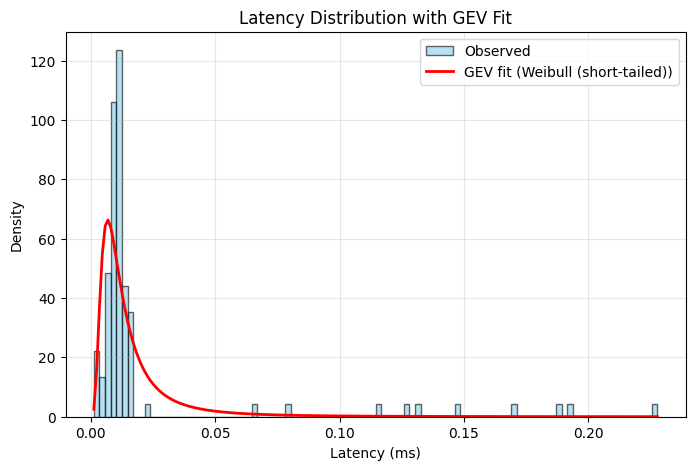

In [77]:


if shape > 0:
    dist_type = "Fréchet (heavy-tailed)"
elif shape < 0:
    dist_type = "Weibull (short-tailed)"
else:
    dist_type = "Gumbel (light-tailed)"

print(f"GEV fit parameters:")
print(f"  Shape (ξ): {shape:.4f}")
print(f"  Location (μ): {loc:.4f}")
print(f"  Scale (σ): {scale:.4f}")
print(f"Identified type: {dist_type}")


x = np.linspace(min(latencies), max(latencies), 200)
pdf_fitted = genextreme.pdf(x, shape, loc, scale)

plt.figure(figsize=(8,5))
plt.hist(latencies, bins=100, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Observed")
plt.plot(x, pdf_fitted, 'r-', lw=2, label=f"GEV fit ({dist_type})")
plt.xlabel("Latency (ms)")
plt.ylabel("Density")
plt.title("Latency Distribution with GEV Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

GPD tail fit above u=93.5 ms: xi=0.053, beta=0.0887 s


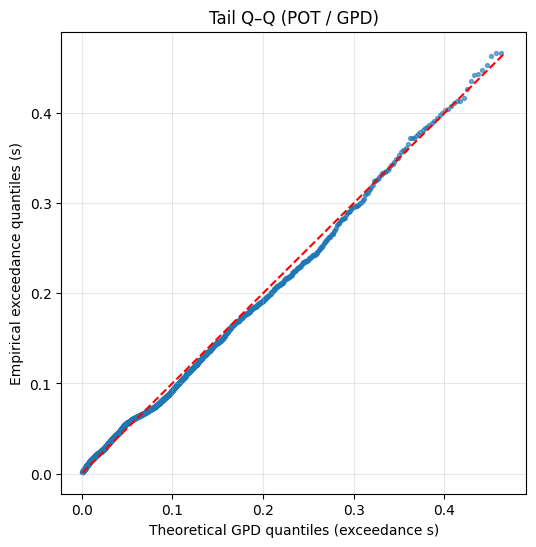

In [78]:
# Fit the tail only with Generalized Pareto (GPD)

x = latencies_s
u = np.quantile(x, 0.95)           
y = x[x > u] - u                    
c, loc, beta = genpareto.fit(y, floc=0)  

print(f"GPD tail fit above u={u*1000:.1f} ms: xi={c:.3f}, beta={beta:.4f} s")

# QQ plot for tail
q = np.linspace(0.01, 0.99, min(len(y), 2000))
q_theo = genpareto.ppf(q, c, loc=0, scale=beta)
q_emp  = np.quantile(y, q)

plt.figure(figsize=(6,6))
plt.scatter(q_theo, q_emp, s=8, alpha=0.6)
lo, hi = float(min(q_theo.min(), q_emp.min())), float(max(q_theo.max(), q_emp.max()))
plt.plot([lo,hi],[lo,hi],'r--'); plt.grid(True, alpha=0.3)
plt.xlabel("Theoretical GPD quantiles (exceedance s)")
plt.ylabel("Empirical exceedance quantiles (s)")
plt.title("Tail Q–Q (POT / GPD)")
plt.show()


lognormal body fit: shape=0.462, scale=0.010863 s


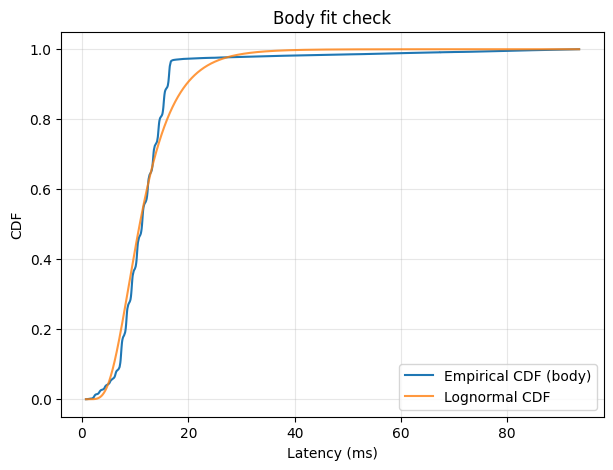

In [79]:
# Fit lognormal to body 

body = x[x <= u]
shape, loc, scale = lognorm.fit(body, floc=0)
print(f"lognormal body fit: shape={shape:.3f}, scale={scale:.6f} s")

# Visual check: ECDF vs lognormal CDF for the body
def ecdf(z): 
    z = np.sort(z); p = np.arange(1, len(z)+1)/len(z); return z, p

z, p = ecdf(body)
cdf = lognorm.cdf(z, shape, loc=0, scale=scale)

plt.figure(figsize=(7,5))
plt.plot(z*1000, p, label="Empirical CDF (body)")
plt.plot(z*1000, cdf, label="Lognormal CDF", alpha=0.8)
plt.xlabel("Latency (ms)"); plt.ylabel("CDF"); plt.grid(True, alpha=0.3); plt.legend()
plt.title("Body fit check")
plt.show()


m=  2 -> E[max] ≈ 14.26 ms
m=  4 -> E[max] ≈ 17.64 ms
m=  5 -> E[max] ≈ 18.74 ms
m=  8 -> E[max] ≈ 21.07 ms
m= 16 -> E[max] ≈ 24.60 ms
m= 32 -> E[max] ≈ 28.23 ms
m= 64 -> E[max] ≈ 31.98 ms
m=128 -> E[max] ≈ 35.86 ms


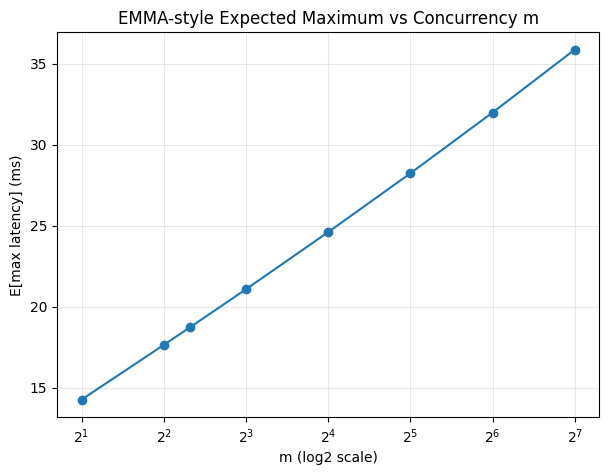

In [64]:
from scipy.optimize import brentq

# --- Build piecewise CDF ---
F_u_body = lognorm.cdf(u, shape, loc=0, scale=scale)  # CDF at threshold

def F_lat(t):
    """Piecewise CDF for latency."""
    t = np.asarray(t, float)
    res = np.zeros_like(t)
    # body
    m = t <= u
    res[m] = lognorm.cdf(t[m], shape, loc=0, scale=scale)
    # tail
    mt = ~m
    if np.any(mt):
        yy = t[mt] - u
        res[mt] = F_u_body + (1 - F_u_body) * genpareto.cdf(yy, c, loc=0, scale=beta)
    return res

def Finv_lat(p):
    """Numerical inverse CDF."""
    return brentq(lambda z: F_lat(z) - p, x.min(), u + 20*beta)

# --- EMMA/Blom expected maximum ---
def expected_max_emma(m):
    pm = (m - 0.375) / (m + 0.25)
    pm = min(max(pm, 1e-12), 1 - 1e-12)
    return Finv_lat(pm)

# Example: evaluate for a few concurrency levels
ms = [2, 4, 5, 8, 16, 32, 64, 128]
for m in ms:
    em = expected_max_emma(m)
    print(f"m={m:>3d} -> E[max] ≈ {em*1000:.2f} ms")

# --- Plot expected max vs m ---
ems = [expected_max_emma(m) for m in ms]
plt.figure(figsize=(7,5))
plt.plot(ms, np.array(ems)*1000, marker="o")
plt.xscale("log", base=2)
plt.xlabel("m (log2 scale)")
plt.ylabel("E[max latency] (ms)")
plt.title("EMMA-style Expected Maximum vs Concurrency m")
plt.grid(True, alpha=0.3)
plt.show()


In [71]:
 ## Non-parametric bootstrap on observed maxima 

folder_path = "./results/20250810_211308/consumer/consumer-sts-0_consumer-result/2025-08-10/20-25-02/"
csv_paths = sorted(glob.glob(folder_path + "*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSVs found in {folder_path}")

# Build per-batch maxima (seconds)
x_max = []
for path in csv_paths:
    df = pd.read_csv(path)
    s = pd.to_numeric(df["end_to_end_latency_seconds"], errors="coerce")
    x_max.append(np.nanmax(s.values))  # ignore NaNs when taking the max
x_max = np.array(x_max, dtype=float)
x_max = x_max[np.isfinite(x_max)]
if x_max.size == 0:
    raise ValueError("No valid maxima found.")

print(f"batches={x_max.size}, mean batch max={x_max.mean()*1000:.2f} ms, "
      f"p95 batch max={np.percentile(x_max,95)*1000:.2f} ms")

rng = np.random.default_rng(0)
B = 2000

# ===== Option A: CI for the mean of batch maxima =====
boot_mean = []
for _ in range(B):
    sample = rng.choice(x_max, size=x_max.size, replace=True)
    boot_mean.append(sample.mean())
ci_mean = np.percentile(boot_mean, [2.5, 97.5])
print(f"Mean(batch max) 95% CI: [{ci_mean[0]*1000:.2f}, {ci_mean[1]*1000:.2f}] ms")

# ===== Option B: CI for the maximum across k batches (scale-up) =====
k = 1  # set to your scale (e.g., k=5, 10, 50)
boot_maxk = []
for _ in range(B):
    # resample the empirical distribution of batch maxima
    resampled = rng.choice(x_max, size=x_max.size, replace=True)
    # draw k maxima from that resampled dist and take the max (non-parametric EV bootstrap)
    draw = rng.choice(resampled, size=k, replace=True)
    boot_maxk.append(draw.max())
ci_maxk = np.percentile(boot_maxk, [2.5, 97.5])
print(f"Max over k={k} batches 95% CI: [{ci_maxk[0]*1000:.2f}, {ci_maxk[1]*1000:.2f}] ms")


batches=575, mean batch max=226.43 ms, p95 batch max=499.52 ms
Mean(batch max) 95% CI: [214.09, 238.81] ms
Max over k=1 batches 95% CI: [16.62, 569.63] ms


In [73]:
m_values = np.array([2,3,4,5,8,16,32,64])
def emma(c, loc, scale, m):
    P = 0.5703760021 / m
    return gev.ppf(P, c, loc=loc, scale=scale)

# EMMA curve
emma_curve = np.array([emma(c, loc, scale, m) for m in m_values])

# Parametric bootstrap of EMMA
B = 2000
emma_boot = np.zeros((B, len(m_values)))
rng = np.random.default_rng(1)
for b in range(B):
    # re-fit by parametric bootstrap: simulate new maxima sample and refit
    sim = gev.rvs(c, loc=loc, scale=scale, size=len(x_max), random_state=rng)
    c_b, loc_b, scale_b = gev.fit(sim)  # If you have MOM/PWM, use those here
    emma_boot[b] = [emma(c_b, loc_b, scale_b, m) for m in m_values]

emma_lo, emma_hi = np.percentile(emma_boot, [2.5, 97.5], axis=0)

In [75]:
xi = -c  # SciPy’s c = -ξ
tail = "Weibull (short)" if xi < 0 else ("Gumbel (light)" if np.isclose(xi,0, atol=1e-2) else "Fréchet (heavy)")
print(f"GEV tail type via ξ: {tail} (xi={xi:.3f})")
def return_level(N, c, loc, scale):
    # Value exceeded on average once every N maxima
    p = 1.0 - 1.0/N
    return gev.ppf(p, c, loc=loc, scale=scale)
print("R_100 (once per 100 batches):", return_level(100, c, loc, scale))



GEV tail type via ξ: Weibull (short) (xi=-0.053)
R_100 (once per 100 batches): 0.044387338653664385


Samples: 57500 | mean=21.00 ms | p95=93.51 ms | p99=238.12 ms

=== POT / GPD threshold sweep ===


,q,u_ms,n_exceed,xi,beta_ms,ks,p
0,0.850,16.116178,8625,3.452410,0.775850,0.194208,1.885337e-285
1,0.900,16.490936,5749,0.148387,81.523732,0.205893,3.336833e-214
2,0.925,20.944476,4313,-0.078762,131.427192,0.099941,5.925983e-38
3,0.950,93.514371,2875,0.052572,88.716872,0.044739,1.940724e-05
4,0.975,157.311708,1438,0.187486,75.112525,0.053530,5.067016e-04


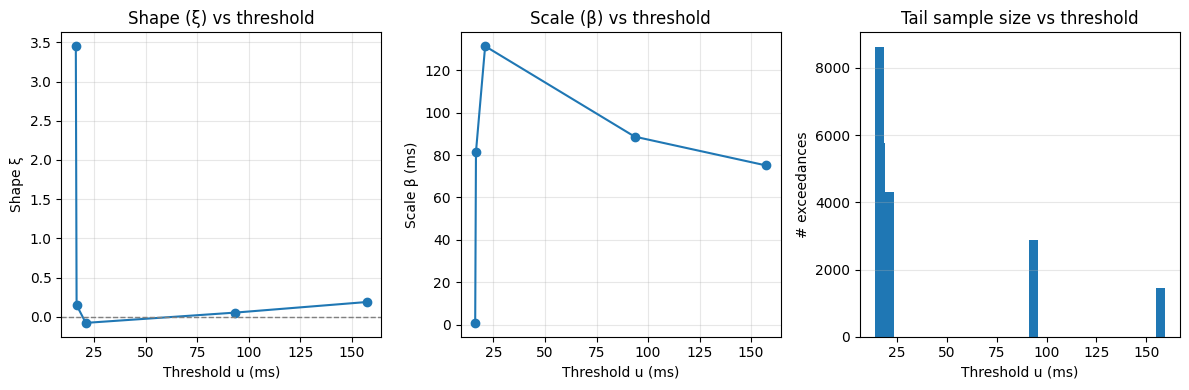


Suggested threshold u ≈ 16.1 ms (xi=3.452, beta=0.78 ms, n_exceed=8625, KS=0.194, p=0.000)


In [49]:
us = np.quantile(x, [0.85,0.90,0.925,0.95,0.975])
xis = []
for uu in us:
    yy = x[x>uu] - uu
    if len(yy) > 50:
        c,_,b = genpareto.fit(yy, floc=0)
        xis.append(c)
        print(f"u={uu*1000:.1f} ms -> xi={c:.3f}  n={len(yy)}")
